# Getting There — transform-system sandbox

Stand-in for the eventual client: load a scenario, submit turns (optionally with orders), watch the world evolve. The `sim` package is the pure engine; `viz` is notebook-only rendering.

**Universal decay:** each turn, a location's next contents are *exactly* what its transforms produce — anything not re-emitted is gone. Storage is therefore itself a transform (`air → air` free, `food + energy → food` powered). Death is emergent: an unfed person runs no survival transform and simply isn't there next turn.

Each turn is `run_turn(world, scenario, orders) -> (world', replay)` — the shape the client/server API will take.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # repo root, so `import sim` works

import matplotlib.pyplot as plt

from sim import load_scenario, initial_world, run_turn, scenario_from_dict, SetTransformPriority
import viz

SCENARIO = Path.cwd().parent / "scenarios_data" / "simple-world.json"

## Initial state

Two locations: `greenhouse` feeds `habitat`. Node labels show non-zero resources.

tick 0
  greenhouse: plant:8, energy:4
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  habitat: person:2, food:4, energy:2, air:4
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  TOTALS: person:2, food:4, plant:8, energy:6, air:4


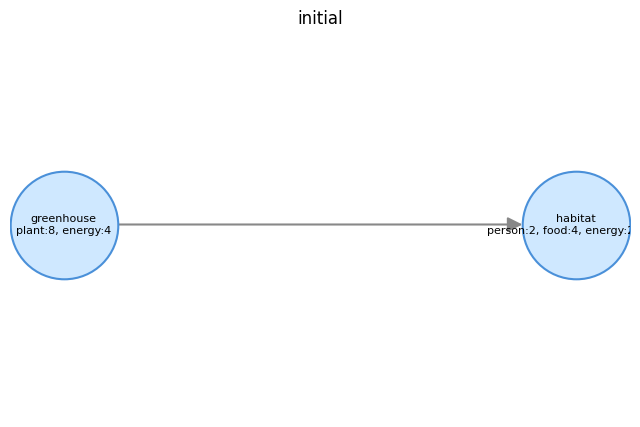

In [2]:
scenario = load_scenario(SCENARIO)
world = initial_world(scenario, seed=0)

print(viz.summarize(world, scenario))
viz.draw_world(world, scenario, title="initial")
plt.show()

## One turn

The replay lists what fired, in evaluation order.

   habitat: farming x2
   habitat: atmosphere x4
   habitat: photosynthesis x2
   habitat: air_storage x2

tick 1
  greenhouse: (empty)
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  habitat: person:2, food:4, plant:6, energy:2, air:6
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  TOTALS: person:2, food:4, plant:6, energy:2, air:6


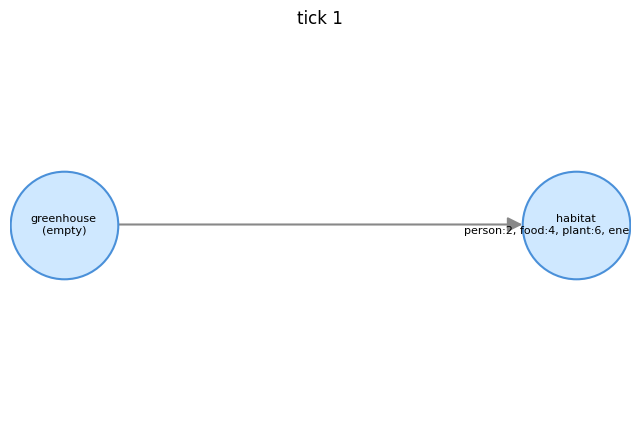

In [3]:
world, replay = run_turn(world, scenario)

for e in replay.events:
    print(f"{e.location_id:>10}: {e.transform} x{e.count}")
print()
print(viz.summarize(world, scenario))
viz.draw_world(world, scenario)
plt.show()

## Six turns, default priorities

Watch the DAG evolve. Because storage is a transform, whatever isn't actively re-emitted drains away — keep an eye on which resources hold and which decay.

In [ ]:
world = initial_world(scenario, seed=0)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax in axes.flat:
    viz.draw_world(world, scenario, ax=ax)
    world, _ = run_turn(world, scenario)
plt.tight_layout()
plt.show()

## The one order: reprioritize a location

The entire MVP order vocabulary is "reorder the transforms at a location." Transforms contend for a shared pool, so priority decides who wins. Below, bumping `photosynthesis` and `growth` to the front of the greenhouse changes what it does with its plants and energy. The change **persists** — later turns keep the policy with no new order.

In [ ]:
world = initial_world(scenario, seed=0)
order = SetTransformPriority("greenhouse", ["photosynthesis", "growth"])

world, _ = run_turn(world, scenario, orders=[order])   # policy set here...
for _ in range(4):
    world, _ = run_turn(world, scenario)                # ...and persists, no new order

print(viz.summarize(world, scenario))
viz.draw_world(world, scenario, title="greenhouse: photosynthesis+growth first, after 5 turns")
plt.show()

## Death is emergent

Under universal decay we no longer need a special rule for starvation. Give 5 people only 2 food: survival can re-emit just 2 of them, and the other 3 are absent next turn. This is the behavior the old persistence model couldn't produce.

In [ ]:
starve = scenario_from_dict({
    "resources": ["person", "food", "air"],
    "transforms": [
        {"name": "survival", "inputs": {"person": 1, "food": 1, "air": 1}, "outputs": {"person": 1}},
        {"name": "air_storage", "inputs": {"air": 1}, "outputs": {"air": 1}},
    ],
    "locations": [{"id": "hab", "resources": {"person": 5, "food": 2, "air": 8}, "destinations": []}],
    "evaluation_order": ["hab"],
})
w = initial_world(starve)
for t in range(4):
    print(viz.summarize(w, starve).splitlines()[1])  # habitat line
    w, _ = run_turn(w, starve)